# Computer Vision Using Deep Learning - Practical 3

Original Grayscale Image:


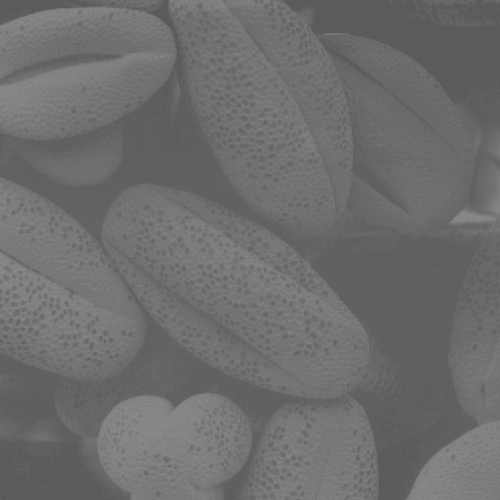

In [1]:
import cv2
import os
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np

image_path = 'input.tif'

if os.path.exists(image_path):

    original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if original_image is not None:
        print("Original Grayscale Image:")
        cv2_imshow(original_image)
    else:
        print(f"Failed to read image at {image_path}")
else:
    print(f"File not found: {image_path}")


***HISTOGRAM EQUALIZATION***


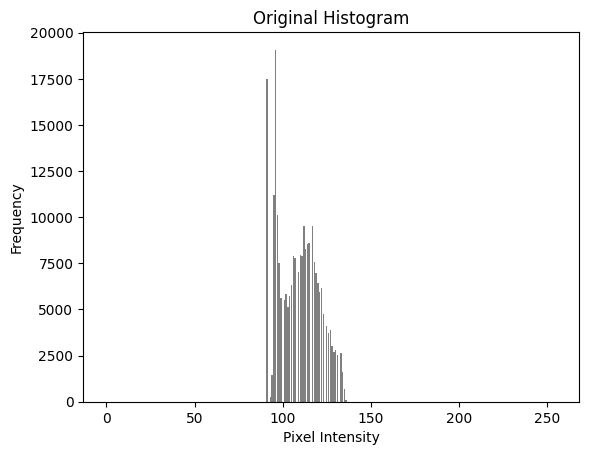

In [ ]:
hist = [0] * 256
rows, cols = original_image.shape

for i in range(rows):
    for j in range(cols):
        pixel_val = original_image[i, j]
        hist[pixel_val] += 1

plt.bar(range(256), hist, color='gray')
plt.title("Original Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

In [3]:

cdf = [0] * 256
cdf[0] = hist[0]
for i in range(1, 256):
    cdf[i] = cdf[i - 1] + hist[i]

cdf_min = min(val for val in cdf if val > 0)
total_pixels = rows * cols

normalized_cdf = [0] * 256
for i in range(256):
    normalized_cdf[i] = round((cdf[i] - cdf_min) / (total_pixels - cdf_min) * 255)


Equalized Image:


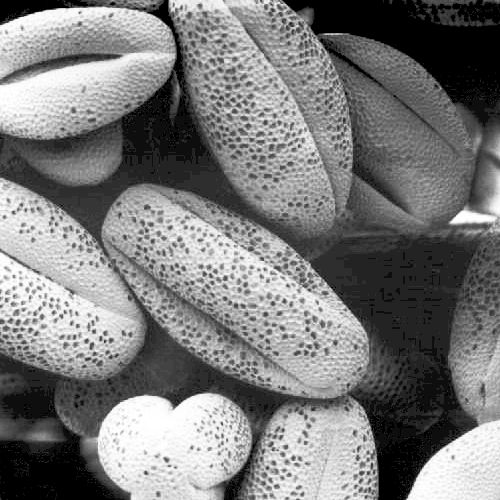

In [4]:
equalized_image = np.zeros_like(original_image)

for i in range(rows):
    for j in range(cols):
        equalized_image[i, j] = normalized_cdf[original_image[i, j]]

print("Equalized Image:")
cv2_imshow(equalized_image)


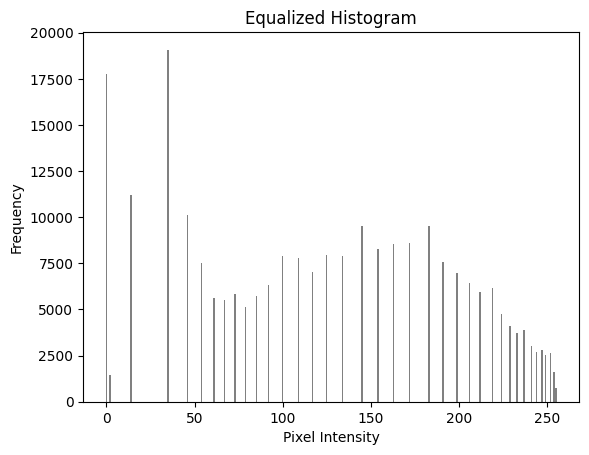

In [5]:

equalized_hist = [0] * 256
for i in range(rows):
    for j in range(cols):
        equalized_hist[equalized_image[i, j]] += 1

plt.bar(range(256), equalized_hist, color='gray')
plt.title("Equalized Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()


***BIT PLANE SLICING***

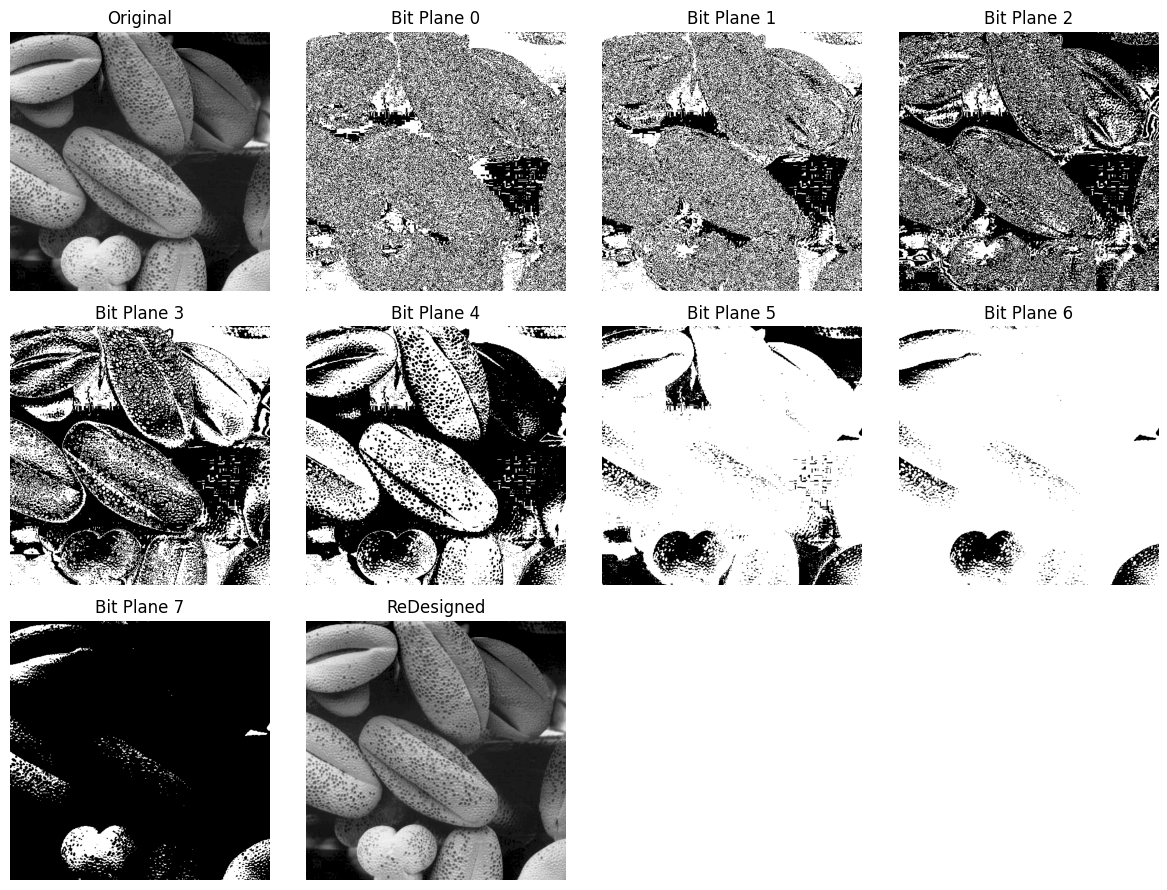

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('input.tif', cv2.IMREAD_GRAYSCALE)

bit_planes = []

plt.figure(figsize=(12, 9))

plt.subplot(3, 4, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

for i in range(8):
    bit_mask = 1 << i
    bit_plane = cv2.bitwise_and(img, bit_mask)
    bit_plane_vis = np.where(bit_plane > 0, 255, 0).astype(np.uint8)
    bit_planes.append(bit_plane_vis)

    plt.subplot(3, 4, i + 2)
    plt.imshow(bit_plane_vis, cmap='gray')
    plt.title(f'Bit Plane {i}')
    plt.axis('off')

reconstructed = np.zeros_like(img)
for i in range(8):
    reconstructed += (bit_planes[i] // 255) * (1 << i)

plt.subplot(3, 4, 10)
plt.imshow(reconstructed, cmap='gray')
plt.title('ReDesigned')
plt.axis('off')

plt.tight_layout()
plt.show()
